In [6]:
!pip install yfinance -q

### 데이터 뽑아오기

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# 1. 분석 대상 자산의 야후 파이낸스 티커 매핑
tickers = {
    'KOSPI 200': '^KS200', #기준 자산
    'KRW/USD': 'KRW=X',
    'USD/CNY': 'CNY=X',
    'KRW/JPY': 'JPYKRW=X',
    'Gold Spot': 'GC=F',
    'TOPIX': '1306.T',
    'Shanghai Comp': '000001.SS',
    'KODEX 200': '069500.KS',
    'KOSDAQ': '^KQ11',
    'Brent Crude Oil': 'BZ=F'
}

# 2. 데이터 다운로드
raw_data = yf.download(list(tickers.values()), start='2008-01-01', end='2026-02-28')['Close']
name_mapping = {v: k for k, v in tickers.items()}
data = raw_data.rename(columns=name_mapping)

# 3. 위안화/원화 교차 환율 계산 (@성택 KRW/CNY 환율 계산에서 0값이 나오는 오류가 있었음. 교차 환율로 오류 수정함.)
data['KRW/CNY'] = data['KRW/USD'] / data['USD/CNY']

# 4. KOSPI 200 영업일 기준으로 시계열 정렬
# KOSPI 200 지수가 존재하는 날짜만 추출 (주말 및 공휴일 제외)
reference_index = data['KOSPI 200'].dropna().index

# 모든 자산을 KOSPI 200 날짜에 맞춰 재색인하고, 휴장일은 직전 데이터로 채움
data = data.reindex(reference_index).ffill()

#________________________________________________________________________________

data_2008=data.copy() #파생변수 (MA,EMA 등) 계산을 위한 원본 데이터 백업

# 5. 분석 시작일 고정 (KODEX 200 상장일인 2009년 4월 17일 유지 혹은 전체 데이터 사용 가능)
data = data.loc['2009-04-17':]
data_2009=data.copy() 


[*********************100%***********************]  10 of 10 completed


In [18]:
#data_8을 csv파일로 저장하는 코드
data_2008.to_csv(r'C:\Users\dddhs\TS_RL_proj\data\raw\data_2008.csv', index=True,encoding="utf-8-sig") # 2008년부터 데이터
data_2009.to_csv(r'C:\Users\dddhs\TS_RL_proj\data\raw\data_2009.csv', index=True,encoding="utf-8-sig") # 2009년 4월 17일부터 데이터


### 데이터 시각화

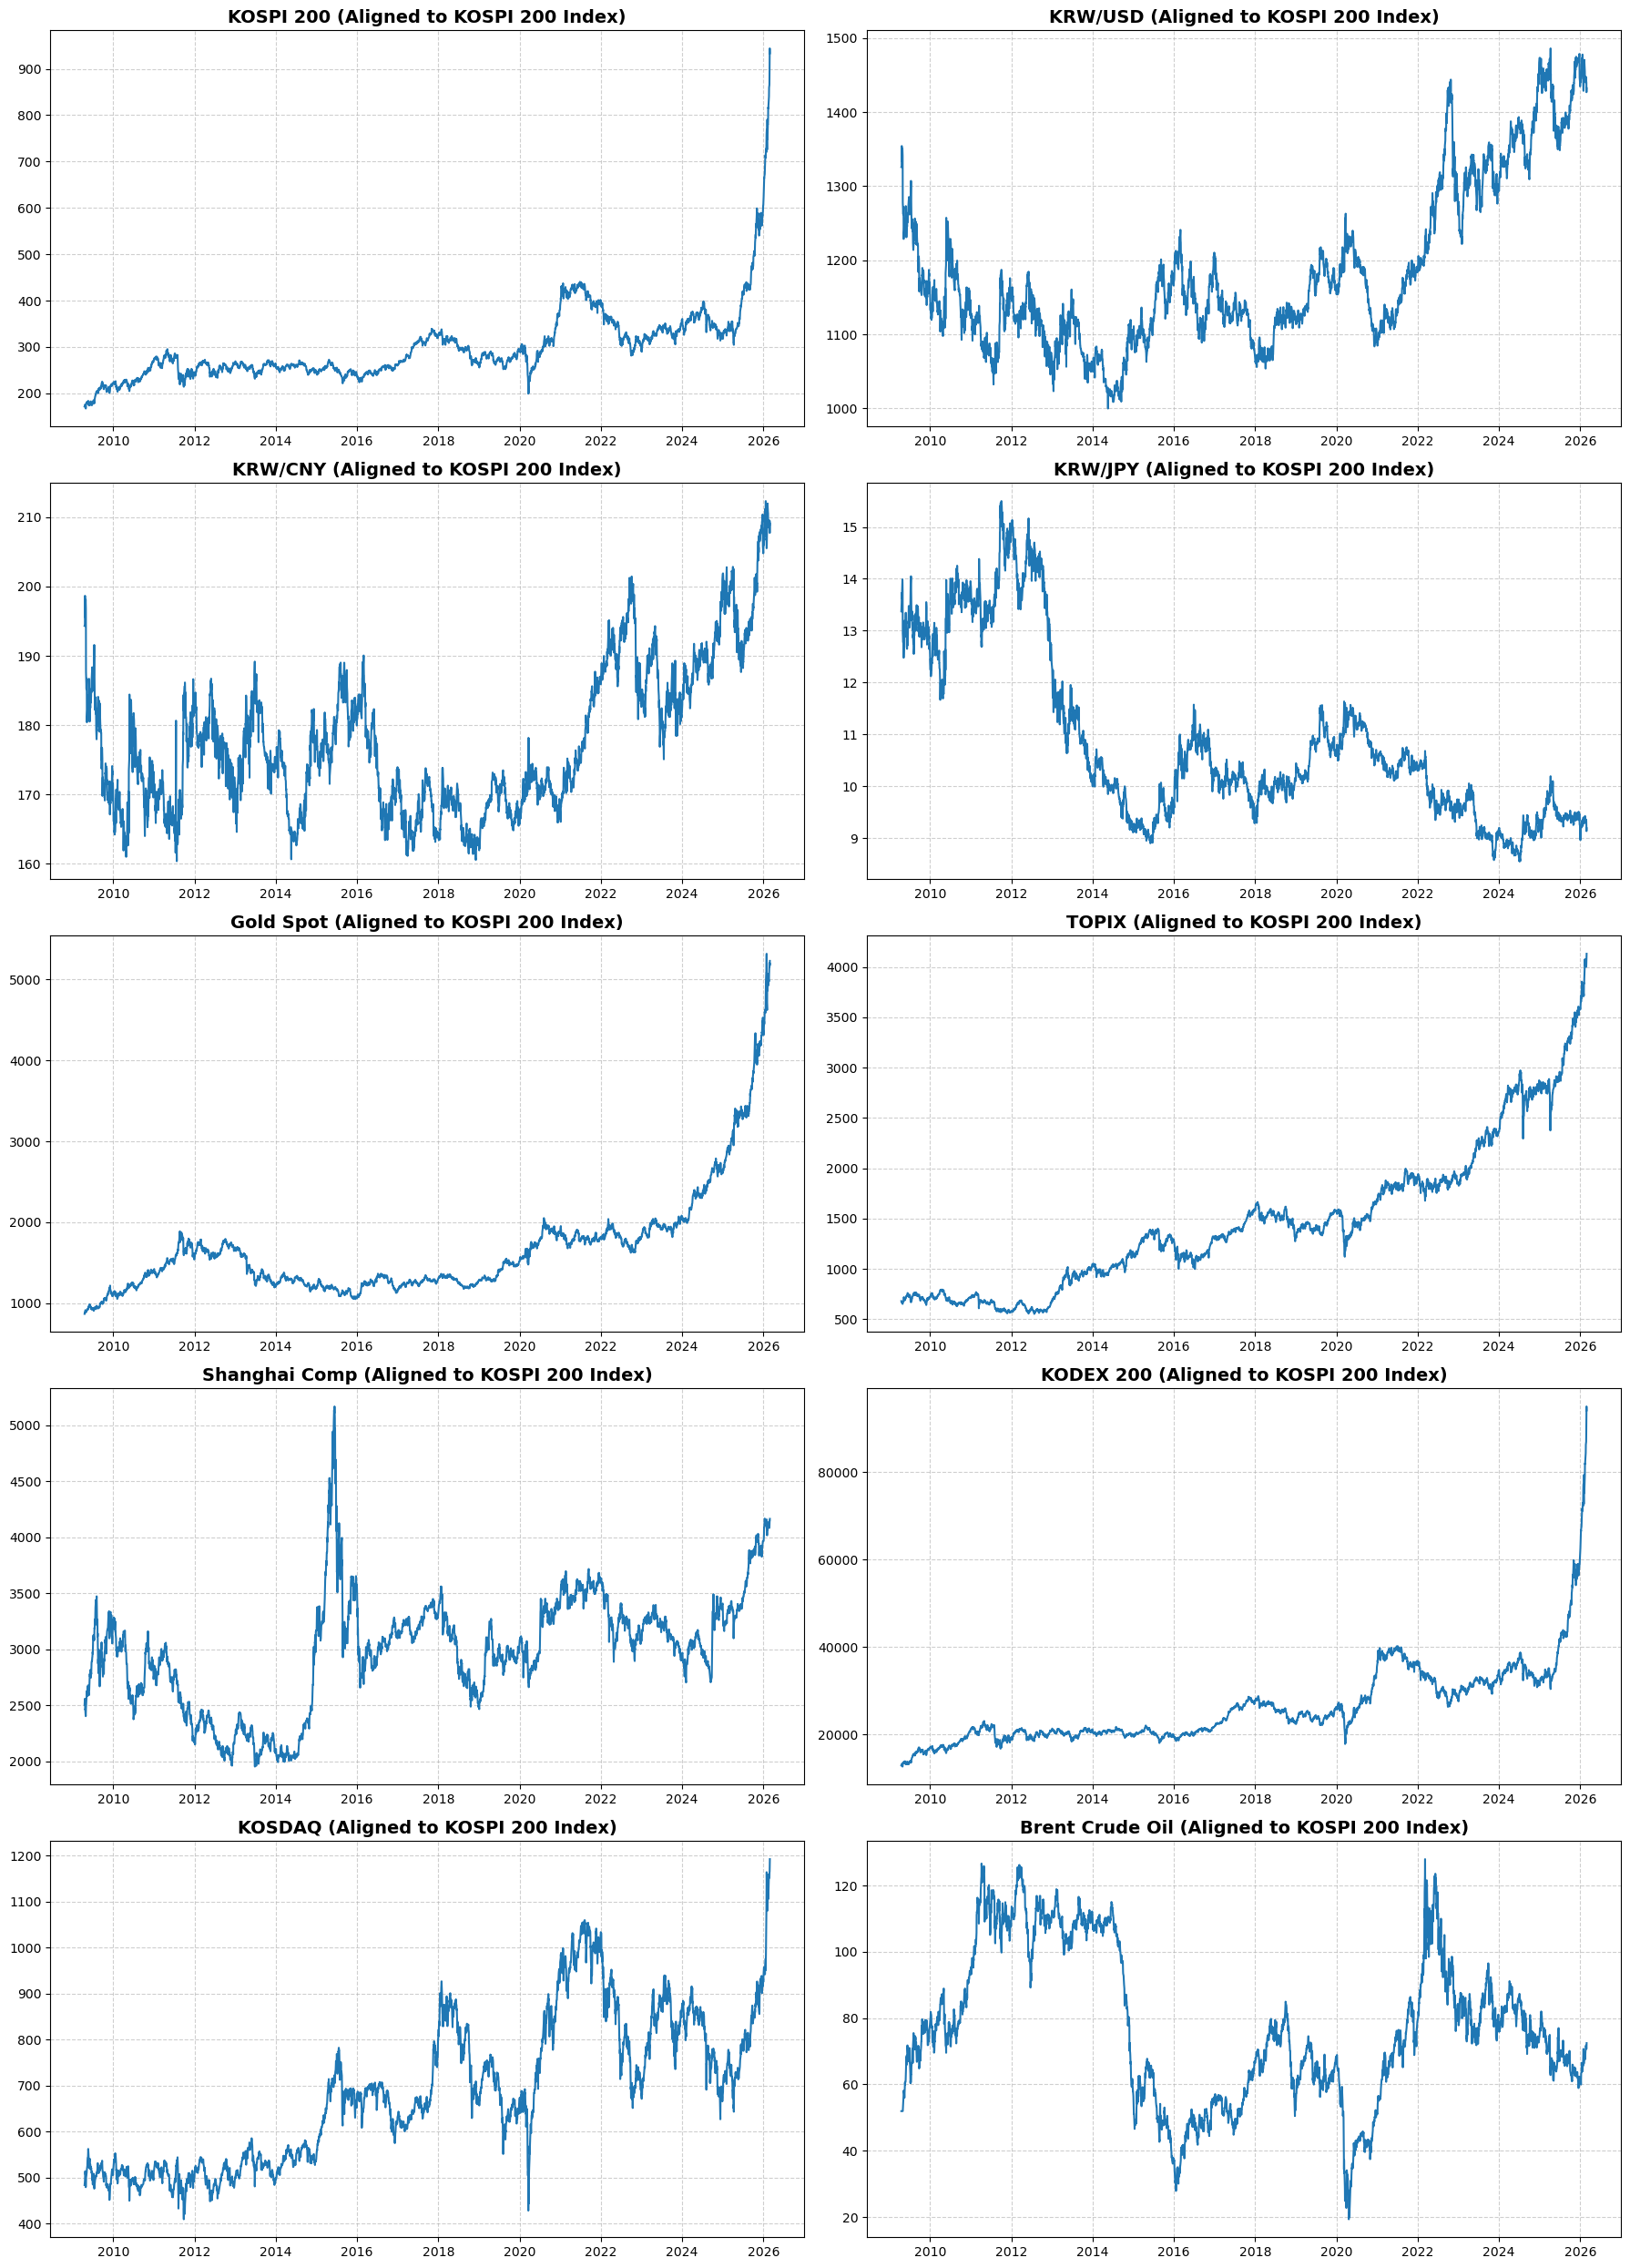

--- KOSPI 200 기준 정렬 검증 ---
전체 데이터 기간: 2009-04-17 ~ 2026-02-27
총 영업일 수: 4109일


Ticker,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,USD/CNY,Gold Spot,KRW/JPY,KRW/USD,KOSDAQ,KOSPI 200,KRW/CNY
Date,,,,,,,,,,,
2009-04-17,2503.935059,12910.509766,679.428528,51.959999,6.8226,867.400024,13.371,1325.800049,483.799988,171.330002,194.324755
2009-04-20,2557.456055,12992.271484,680.204834,51.959999,6.8230,887.000000,13.536,1327.500000,491.940002,172.300003,194.562510
2009-04-21,2535.827881,12992.271484,663.898682,51.959999,6.8169,882.099976,13.727,1354.300049,497.190002,171.960007,198.668030
2009-04-22,2461.345947,13166.940430,664.675171,51.959999,6.8195,891.799988,13.726,1346.599976,509.899994,174.399994,197.463154
2009-04-23,2463.954102,13300.724609,669.333923,51.959999,6.8193,905.900024,13.618,1333.599976,514.090027,176.139999,195.562586


In [23]:
# 6. 시각화
plot_cols = ['KOSPI 200', 'KRW/USD', 'KRW/CNY', 'KRW/JPY', 'Gold Spot', 'TOPIX', 'Shanghai Comp', 'KODEX 200', 'KOSDAQ', 'Brent Crude Oil']

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if col in data.columns:
        series = data[col].dropna()
        axes[i].plot(series.index, series.values, label=col, color='tab:blue')
        axes[i].set_title(f"{col} (Aligned to KOSPI 200 Index)", fontsize=14, fontweight='bold')
        axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 최종 검증
print("--- KOSPI 200 기준 정렬 검증 ---")
print(f"전체 데이터 기간: {data.index.min().date()} ~ {data.index.max().date()}")
print(f"총 영업일 수: {len(data)}일")
display(data.head())

### 결측치 확인

In [25]:


# 1. 정제된 데이터(data)에서의 결측치 확인
final_na_counts = data_2009.isna().sum()

print("--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---")
print(final_na_counts)

print("\n--- 데이터 품질 검증 (시작일 및 샘플) ---")
for col in data_2009.columns:
    first_valid = data_2009[col].first_valid_index()
    last_val = data_2009[col].iloc[-1]
    print(f"{col:15} | 시작일: {first_valid.date()} | 최근값: {last_val:10.2f} | 남은 NaN: {data_2009[col].loc[first_valid:].isna().sum()}")

# 전체 행 수 출력
print(f"\n전체 타임라인 행 수: {len(data_2009)}")

--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---
Ticker
Shanghai Comp      0
KODEX 200          0
TOPIX              0
Brent Crude Oil    0
USD/CNY            0
Gold Spot          0
KRW/JPY            0
KRW/USD            0
KOSDAQ             0
KOSPI 200          0
KRW/CNY            0
dtype: int64

--- 데이터 품질 검증 (시작일 및 샘플) ---
Shanghai Comp   | 시작일: 2009-04-17 | 최근값:    4162.88 | 남은 NaN: 0
KODEX 200       | 시작일: 2009-04-17 | 최근값:   94120.00 | 남은 NaN: 0
TOPIX           | 시작일: 2009-04-17 | 최근값:    4131.00 | 남은 NaN: 0
Brent Crude Oil | 시작일: 2009-04-17 | 최근값:      72.48 | 남은 NaN: 0
USD/CNY         | 시작일: 2009-04-17 | 최근값:       6.84 | 남은 NaN: 0
Gold Spot       | 시작일: 2009-04-17 | 최근값:    5230.50 | 남은 NaN: 0
KRW/JPY         | 시작일: 2009-04-17 | 최근값:       9.19 | 남은 NaN: 0
KRW/USD         | 시작일: 2009-04-17 | 최근값:    1432.32 | 남은 NaN: 0
KOSDAQ          | 시작일: 2009-04-17 | 최근값:    1192.78 | 남은 NaN: 0
KOSPI 200       | 시작일: 2009-04-17 | 최근값:     933.34 | 남은 NaN: 0
KRW/CNY         | 시작일: 2009-04-17 | 최근값:   